# Event 06 — Fed 역대급 긴축 사이클 (2022~2023)
## 스토리텔링 차트 (Scrollytelling Stepper)

### 배경
2022년 한 해, Fed는 **0.25% → 4.50%로 +425bp 인상**. 75bp 인상을 4연속 단행하는 등, 1980년대 Volcker 이후 가장 공격적인 긴축 사이클. 같은 해 6월부터는 **QT(양적긴축)**도 병행 — 대차대조표 $8.94T → $8.43T로 축소.

### 주가 충격
SP500은 연초 고점 4,797 → 10월 저점 3,577 (**-25%**, 전형적 베어마켓)

### 출력
- `data/figures/e06_story/00_prologue.png` … `05_act5.png`
- `data/figures/e06_story/99_summary.png`

## 1. Imports & 데이터 로드

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
PANEL = ROOT / 'data' / 'processed' / 'panel_daily.csv'
FIG_DIR = ROOT / 'data' / 'figures' / 'e06_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# SP500
panel = pd.read_csv(PANEL, index_col=0, parse_dates=True)
sp = panel.loc['2022-01-03':'2023-03-31', 'SP500'].copy()

# Fed Rate — FOMC 인상 실제 날짜를 step function으로 구성 (상한 기준)
hikes = [
    ('2022-01-03', 0.25),  # 사이클 시작점 (0~0.25%)
    ('2022-03-16', 0.50),  # +25bp
    ('2022-05-04', 1.00),  # +50bp
    ('2022-06-15', 1.75),  # +75bp (1994년 이후 최초)
    ('2022-07-27', 2.50),  # +75bp
    ('2022-09-21', 3.25),  # +75bp
    ('2022-11-02', 4.00),  # +75bp (4연속)
    ('2022-12-14', 4.50),  # +50bp (속도 조절)
    ('2023-02-01', 4.75),  # +25bp
    ('2023-03-22', 5.00),  # +25bp
]
hike_df = pd.DataFrame(hikes, columns=['date','rate'])
hike_df['date'] = pd.to_datetime(hike_df['date'])
hike_df = hike_df.set_index('date')

# Daily rate (step-ffill)
idx = pd.date_range('2022-01-03', '2023-03-31', freq='D')
rate = hike_df.reindex(idx).ffill()['rate']
print(f'SP500 range: {sp.min():.0f} ~ {sp.max():.0f}')
print(f'Rate    range: {rate.min():.2f}% ~ {rate.max():.2f}%')
print(f'Total hikes: {len(hikes)-1} ({(hike_df["rate"].iloc[-1] - hike_df["rate"].iloc[0])*100:.0f}bp)')

SP500 range: 3577 ~ 4797
Rate    range: 0.25% ~ 5.00%
Total hikes: 9 (475bp)


## 2. 6국면 정의 (인상 페이스에 맞춤)

In [2]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 긴축 예고',
        'start': '2022-01-03', 'end': '2022-03-15', 'color': '#90A4AE',
        'narrative': 'CPI가 7%대까지 올라오며 Fed 매파 선회가 기정사실. SP500은 연초 고점(4,797)에서 4,200대까지 선반영 하락.',
        'hero_annotations': [
            ('2022-01-03', 'SP500', 4797, 'SP500 연초 고점\n4,797', (-80, 25), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — 첫 인상 +25bp (3/16)',
        'start': '2022-03-16', 'end': '2022-05-03', 'color': '#FFB74D',
        'narrative': '3/16 FOMC에서 +25bp 첫 인상 (0.25% → 0.50%). 2018년 이후 첫 인상. 시장은 안도 반등하며 SP500 4,500대 회복.',
        'hero_annotations': [
            ('2022-03-16', 'RATE',  0.50, '⭐ 첫 인상 +25bp\n목표 0.50%', (15, 20), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — 50bp 가속 (5/4)',
        'start': '2022-05-04', 'end': '2022-06-14', 'color': '#FB8C00',
        'narrative': '5/4 FOMC +50bp (22년만의 속도). 시장은 더 공격적 긴축 전망에 팔리며 SP500이 3,930까지 하락.',
        'hero_annotations': [
            ('2022-05-04', 'RATE', 1.00, '+50bp\n목표 1.00%', (15, 15), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — 75bp 3연속',
        'start': '2022-06-15', 'end': '2022-09-20', 'color': '#E53935',
        'narrative': '6/15 +75bp (1994 이후 첫 초대형), 7/27 +75bp, 9/21 +75bp. 3개월간 +225bp. 같은 6월에 QT도 시작. SP500은 6월 3,636, 9월 다시 3,600대까지 추락.',
        'hero_annotations': [
            ('2022-06-15', 'RATE', 1.75, '⭐ +75bp\n1994 이후 최초\n(QT 개시)', (15, 20), 'left'),
            ('2022-06-17', 'SP500', 3675, 'SP500 중간 저점\n3,675', (-110, -25), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — 75bp 4연속 & 저점',
        'start': '2022-09-21', 'end': '2022-12-13', 'color': '#B71C1C',
        'narrative': '11/2 +75bp 4연속. SP500은 10/13 장중 저점 3,492 (연초 대비 -27%). CPI가 꺾이기 시작하며 12월 속도 조절 기대.',
        'hero_annotations': [
            ('2022-10-13', 'SP500', 3577, '⭐ SP500 연중 저점\n3,577 (-25%)', (-105, 20), 'left'),
            ('2022-11-02', 'RATE',  4.00, '+75bp 4연속\n목표 4.00%', (15, -25), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — 속도 조절 & 고점 부근',
        'start': '2022-12-14', 'end': '2023-03-31', 'color': '#6A1B9A',
        'narrative': '12/14 +50bp, 23년 2월·3월 각 +25bp로 속도 조절. 목표 4.50% → 5.00%. 누적 +475bp는 Volcker 이후 최대 규모의 긴축 사이클.',
        'hero_annotations': [
            ('2022-12-14', 'RATE',  4.50, '속도 조절 +50bp\n목표 4.50%', (-120, 15), 'left'),
            ('2023-03-22', 'RATE',  5.00, '목표 5.00%\n(누적 +475bp)', (-50, 20), 'left'),
        ],
    },
]
pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 긴축 예고,2022-01-03,2022-03-15,#90A4AE,CPI가 7%대까지 올라오며 Fed 매파 선회가 기정사실. SP500은 연초 고점(...
1,act1,Act 1 — 첫 인상 +25bp (3/16),2022-03-16,2022-05-03,#FFB74D,3/16 FOMC에서 +25bp 첫 인상 (0.25% → 0.50%). 2018년 ...
2,act2,Act 2 — 50bp 가속 (5/4),2022-05-04,2022-06-14,#FB8C00,5/4 FOMC +50bp (22년만의 속도). 시장은 더 공격적 긴축 전망에 팔리...
3,act3,Act 3 — 75bp 3연속,2022-06-15,2022-09-20,#E53935,"6/15 +75bp (1994 이후 첫 초대형), 7/27 +75bp, 9/21 +..."
4,act4,Act 4 — 75bp 4연속 & 저점,2022-09-21,2022-12-13,#B71C1C,"11/2 +75bp 4연속. SP500은 10/13 장중 저점 3,492 (연초 대..."
5,act5,Act 5 — 속도 조절 & 고점 부근,2022-12-14,2023-03-31,#6A1B9A,"12/14 +50bp, 23년 2월·3월 각 +25bp로 속도 조절. 목표 4.50..."


## 3. 헬퍼 함수 (Rate step + SP500)

In [3]:
XLIM       = (pd.Timestamp('2022-01-03'), pd.Timestamp('2023-03-31'))
YLIM_RATE  = (0, 5.5)
YLIM_SP    = (3400, 4850)
DIM_COLOR  = '#D0D0D0'


def plot_rate_panel(ax, visible_end, phase):
    mask_v = rate.index <= visible_end
    xv, yv = rate.index[mask_v], rate[mask_v]
    ax.plot(xv, yv, color=DIM_COLOR, lw=2.0, alpha=0.85, drawstyle='steps-post', zorder=2)
    ax.fill_between(xv, yv, 0, color=DIM_COLOR, alpha=0.18, step='post', zorder=1)

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    m = (xv >= ps) & (xv <= pe)
    if m.any():
        ax.plot(xv[m], yv[m], color=phase['color'], lw=3.5, drawstyle='steps-post', zorder=5)
        ax.fill_between(xv[m], yv[m], 0, color=phase['color'], alpha=0.25, step='post', zorder=3)

    # 인상 시점 마커
    for d, r in zip(hike_df.index, hike_df['rate']):
        if d <= visible_end:
            ax.scatter([d], [r], s=35, color='#333', zorder=6,
                       edgecolors='white', lw=1.0)
    ax.set_ylabel('Fed Funds 목표 상단 (%)', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_sp_panel(ax, visible_end, phase):
    mask_v = sp.index <= visible_end
    xv, yv = sp.index[mask_v], sp[mask_v]
    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.85, zorder=2)

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    m = (xv >= ps) & (xv <= pe)
    if m.any():
        ax.plot(xv[m], yv[m], color=phase['color'], lw=3.0, zorder=5,
                marker='o', markersize=3, markerfacecolor=phase['color'],
                markeredgecolor='white', markeredgewidth=0.8)

    ax.set_ylabel('S&P 500', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx):
    phase = phases[idx]
    visible_end = pd.Timestamp(phase['end']) + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.5, 1.3], hspace=0.18)
    ax_rib  = fig.add_subplot(gs[0])
    ax_rate = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_sp   = fig.add_subplot(gs[2], sharex=ax_rib)

    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short, ha='center', va='center',
                    fontsize=9.5 if active else 8,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top','right','bottom','left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}', fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.925, phase['narrative'], ha='center', va='top',
             fontsize=10.5, color='#333', style='italic', wrap=True)

    plot_rate_panel(ax_rate, visible_end, phase)
    plot_sp_panel(ax_sp, visible_end, phase)
    ax_rate.set_ylim(YLIM_RATE)
    ax_sp.set_ylim(YLIM_SP)

    axmap = {'RATE': ax_rate, 'SP500': ax_sp}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date); c = phase['color']
        ax.scatter([d], [y], s=85, color=c, zorder=6, edgecolors='white', lw=1.8)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white', ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    ax_sp.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax_sp.tick_params(axis='x', labelsize=9, rotation=0)
    ax_sp.set_xlabel('2022~2023', fontsize=10.5)
    for ax in (ax_rib, ax_rate):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: FOMC 인상 일자 (Fed Funds 목표 상단) · SP500 일간 종가   ·   검은 점 = 인상 시점',
             ha='center', fontsize=8.5, color='#888', style='italic')
    plt.tight_layout(rect=[0, 0.02, 1, 0.91])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 4. 6프레임 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_26120\1579067549.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.91])


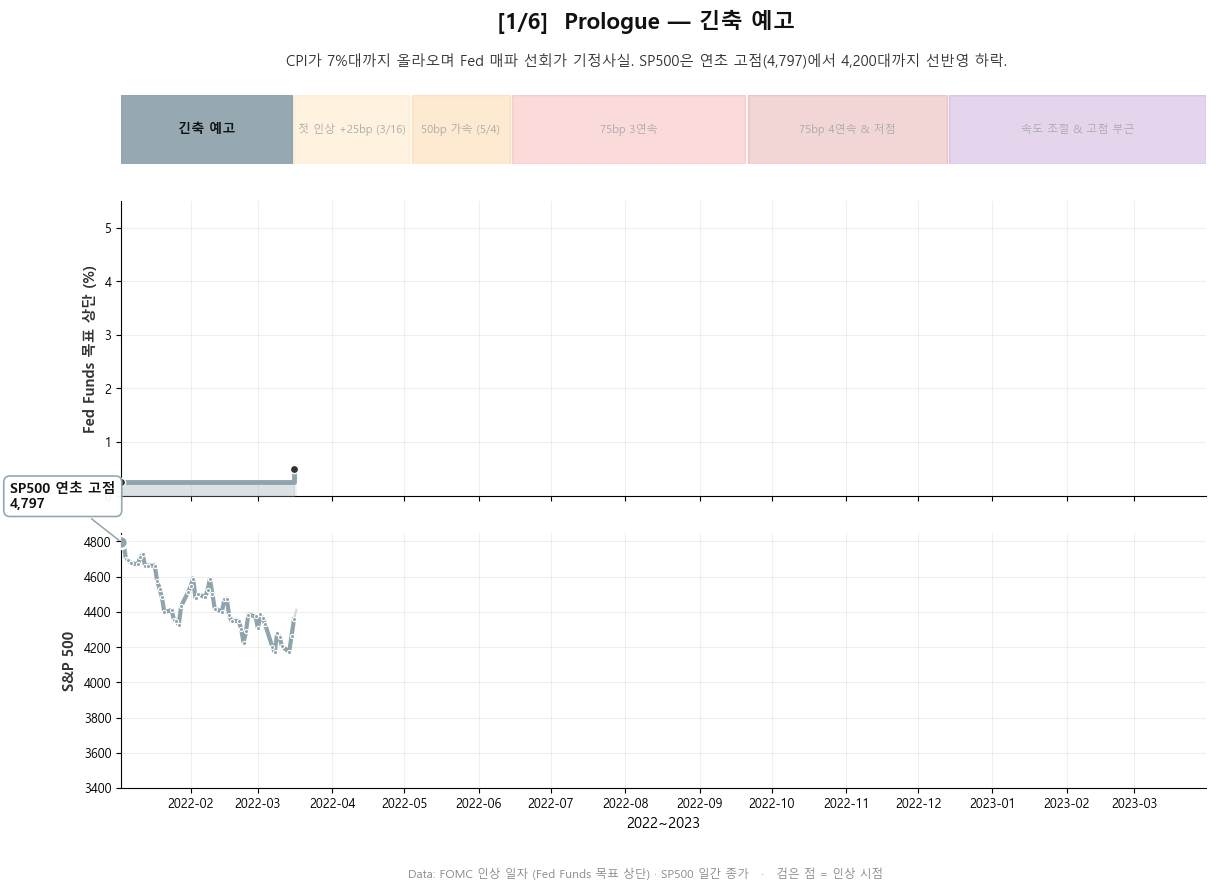

C:\Users\kimch\AppData\Local\Temp\ipykernel_26120\1579067549.py:111: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


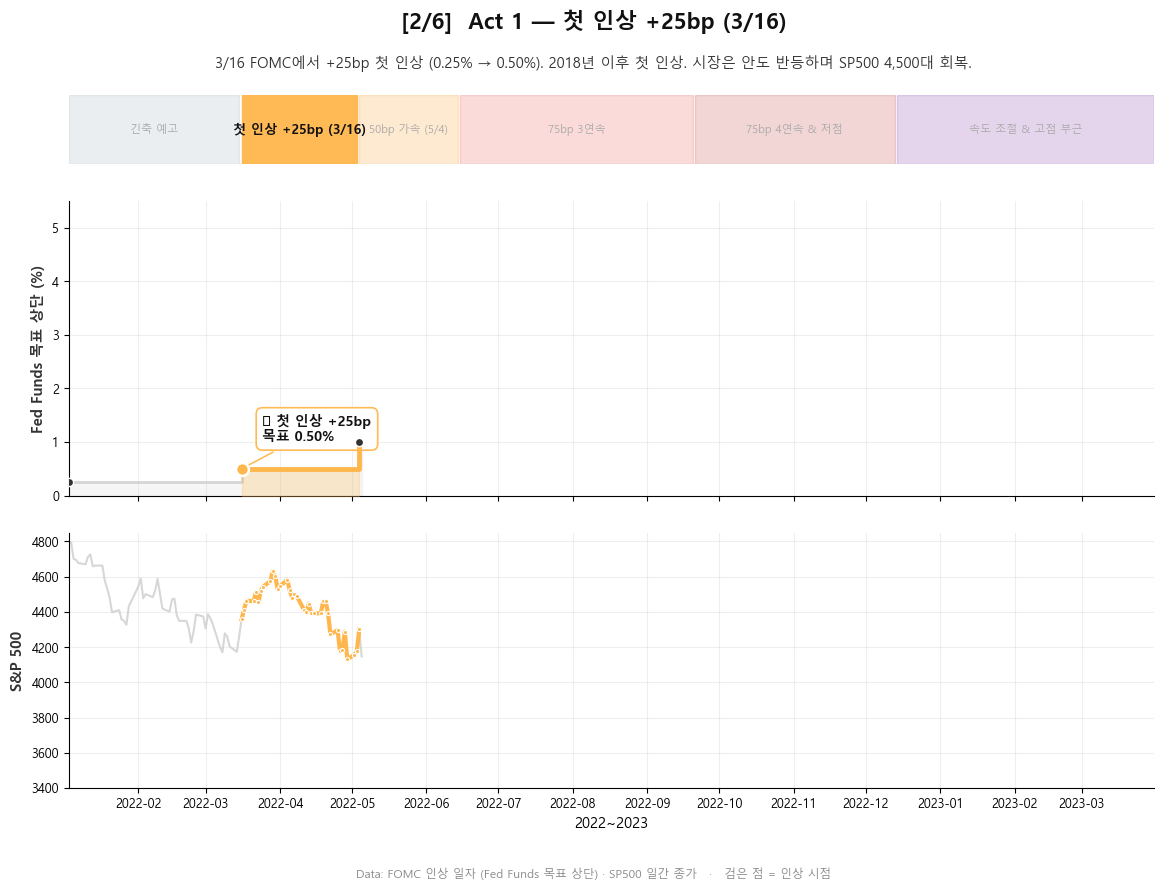

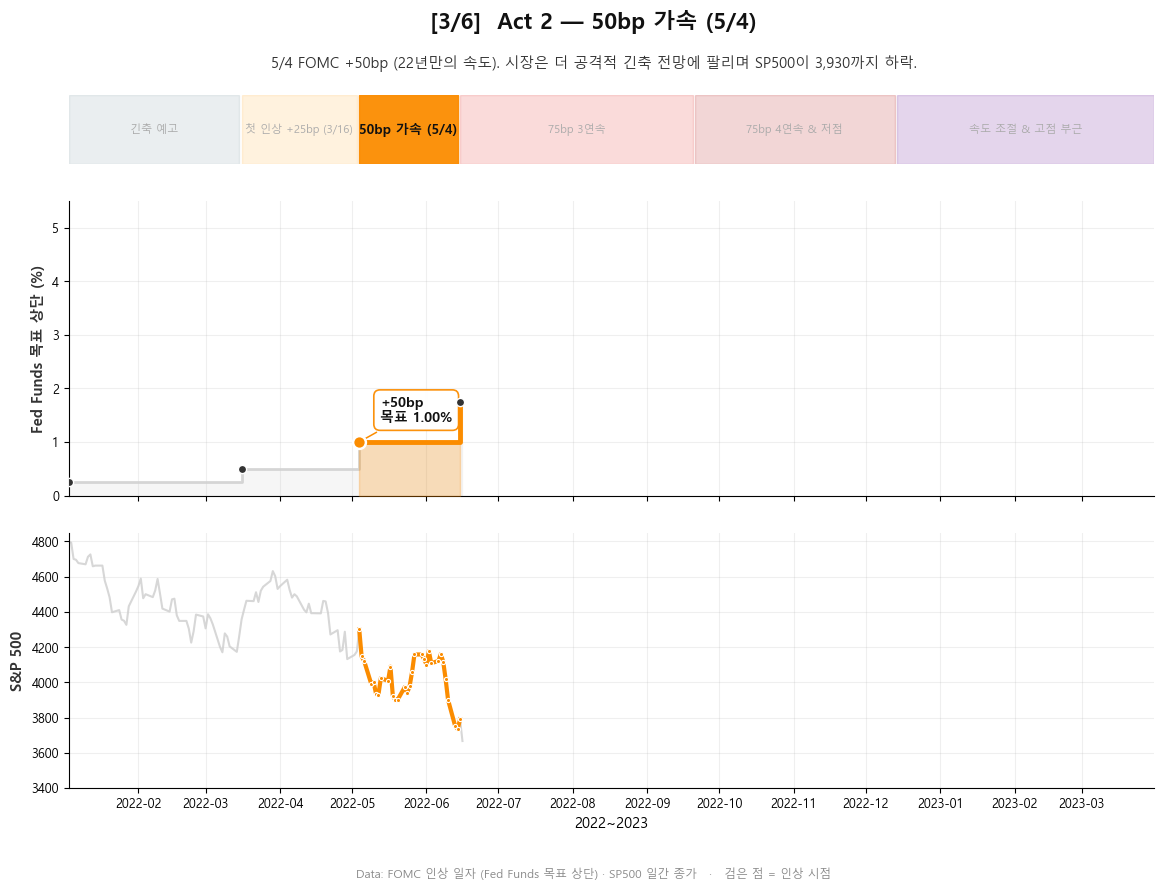

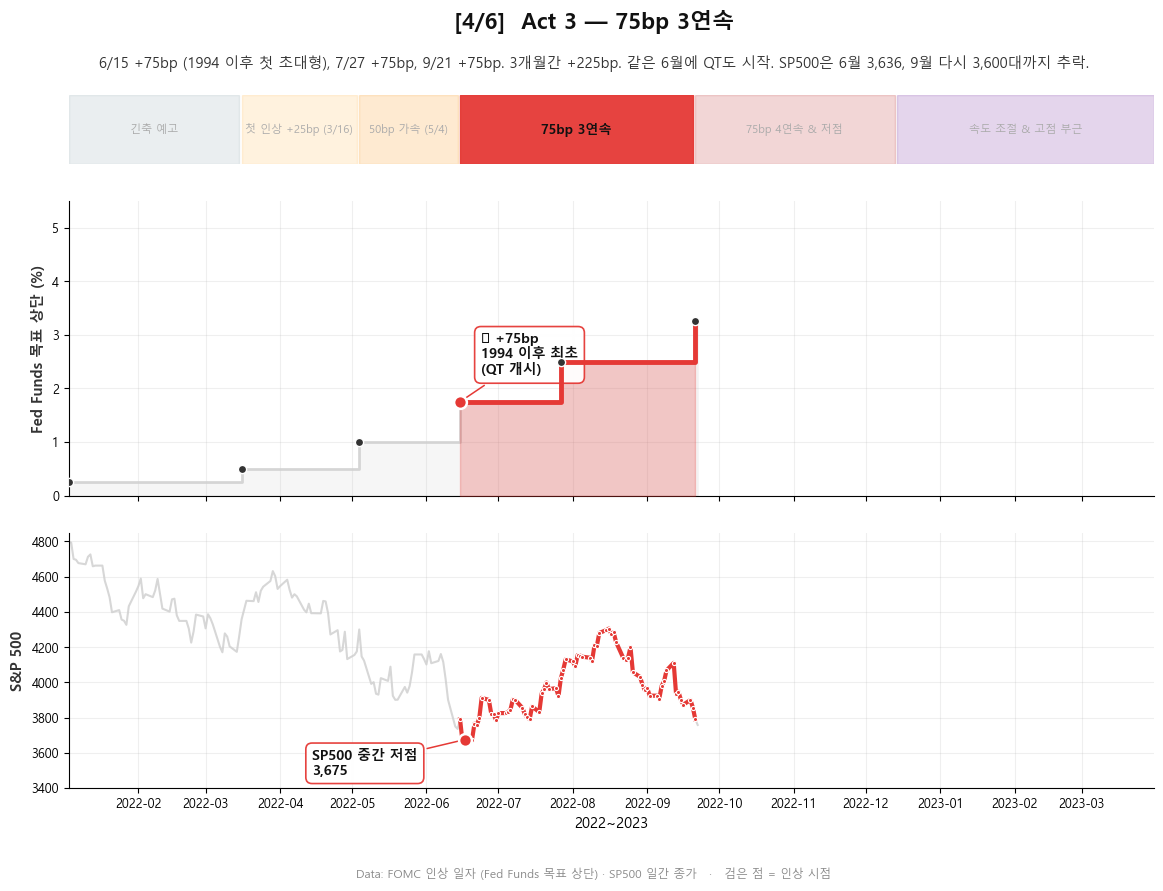

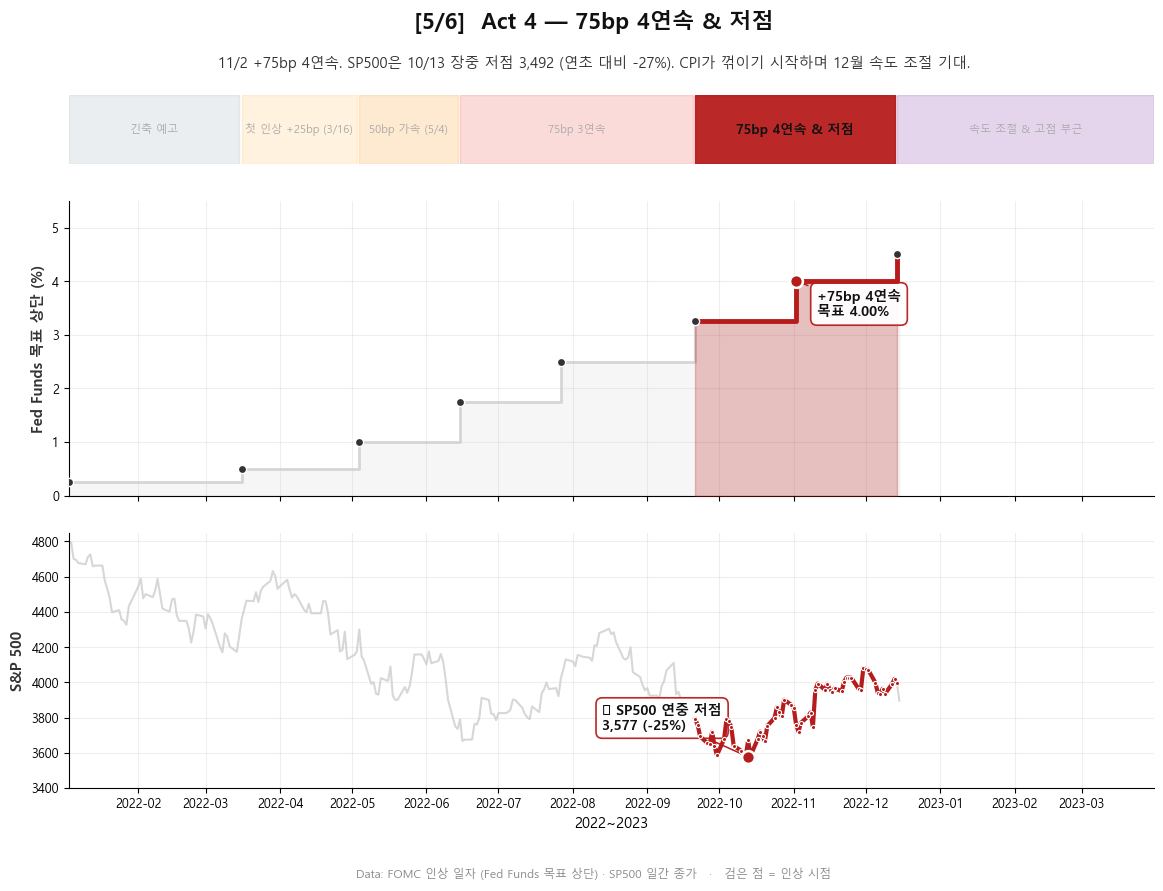

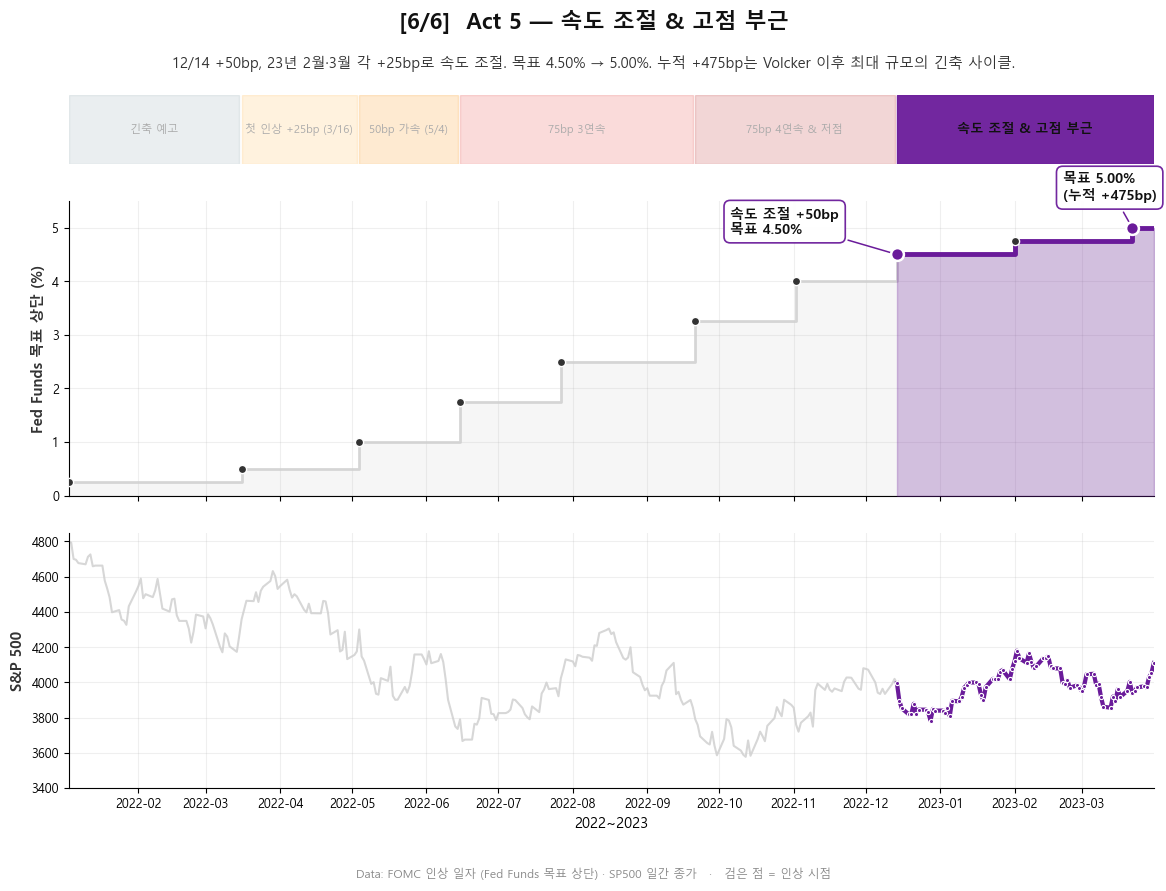

  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\05_act5.png


In [4]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()
for p in saved:
    print(f'  - {p}')

## 5. 종합 프레임

C:\Users\kimch\AppData\Local\Temp\ipykernel_26120\861401791.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.91])
C:\Users\kimch\AppData\Local\Temp\ipykernel_26120\861401791.py:67: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')


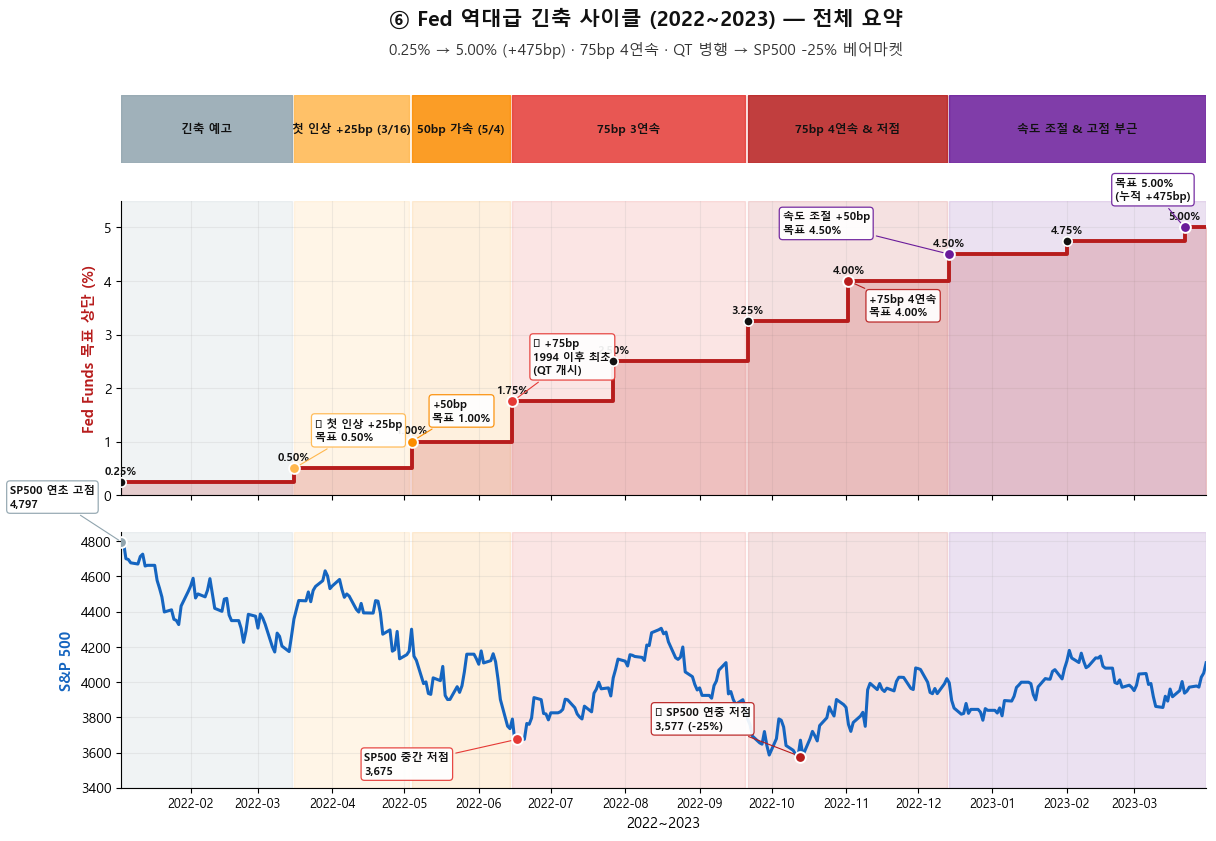


[OK] c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e06_story\99_summary.png


In [5]:
def draw_summary():
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.5, 1.3], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_rate = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_sp = fig.add_subplot(gs[2], sharex=ax_rib)

    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short, ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color='#111')
        for ax in (ax_rate, ax_sp):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top','right','bottom','left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u2465 Fed 역대급 긴축 사이클 (2022~2023) — 전체 요약',
                 fontsize=15, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.925, '0.25% → 5.00% (+475bp) · 75bp 4연속 · QT 병행 → SP500 -25% 베어마켓',
             ha='center', fontsize=11, color='#333', style='italic')

    ax_rate.plot(rate.index, rate, color='#B71C1C', lw=2.8, drawstyle='steps-post', zorder=3)
    ax_rate.fill_between(rate.index, rate, 0, color='#B71C1C', alpha=0.18, step='post', zorder=2)
    for d, r in zip(hike_df.index, hike_df['rate']):
        ax_rate.scatter([d], [r], s=45, color='#111', zorder=5, edgecolors='white', lw=1.2)
        ax_rate.text(d, r + 0.15, f'{r:.2f}%', ha='center', fontsize=8, fontweight='bold', color='#111')
    ax_rate.set_ylabel('Fed Funds 목표 상단 (%)', fontsize=10.5, fontweight='bold', color='#B71C1C')
    ax_rate.set_ylim(YLIM_RATE)
    ax_rate.grid(alpha=0.2)

    ax_sp.plot(sp.index, sp, color='#1565C0', lw=2.2, zorder=3)
    ax_sp.set_ylabel('S&P 500', fontsize=10.5, fontweight='bold', color='#1565C0')
    ax_sp.set_ylim(YLIM_SP)
    ax_sp.grid(alpha=0.2)

    for ax in (ax_rate, ax_sp):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axmap = {'RATE': ax_rate, 'SP500': ax_sp}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date); c = phase['color']
            ax.scatter([d], [y], s=60, color=c, zorder=6, edgecolors='white', lw=1.4)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    ax_sp.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax_sp.tick_params(axis='x', labelsize=9, rotation=0)
    ax_sp.set_xlabel('2022~2023', fontsize=10.5)
    for ax in (ax_rib, ax_rate):
        plt.setp(ax.get_xticklabels(), visible=False)

    plt.tight_layout(rect=[0, 0.02, 1, 0.91])
    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

fig, path = draw_summary()
plt.show()
print(f'\n[OK] {path}')